# **Proyecto Automatidata**  
**Curso 5 - Los conceptos básicos y fundamentales del aprendizaje automático**


Eres un profesional de datos en una empresa de análisis de datos llamada Automatidata. Su cliente, la Comisión de Taxis y Limusinas de la Ciudad de Nueva York (New York City TLC), quedó impresionado con el trabajo que has realizado y ha solicitado que ** construyas un modelo de aprendizaje automático para predecir si un cliente no dejará propina **. Quieren usar el modelo en una aplicación que alertará a los taxistas sobre los clientes que probablemente no dejarán propina, ya que los conductores dependen de las propinas.

Se estructuró y preparó un cuaderno para ayudarte en este proyecto. Por favor, completa las siguientes preguntas.


# Curso 5 Proyecto de fin de curso: Construir un modelo de aprendizaje automático

En esta actividad, practicarás el uso de técnicas de modelado basadas en árboles para predecir en una clase objetivo binaria.  
<br/>   

**El propósito** de este modelo es encontrar formas de generar más ingresos para los conductores de taxis.  
  
**El objetivo** de este modelo es predecir si un cliente es o no un generoso propinador.  
<br/>  

*Esta actividad tiene tres partes:*

**Parte 1:** Consideraciones éticas  
* Considerar las implicaciones éticas de la solicitud 

* ¿Debería ajustarse el objetivo del modelo?

**Parte 2:** Ingeniería de características

* Realizar selección, extracción y transformación de características para preparar los datos para el modelado

**Parte 3:** Modelado

* Construir los modelos, evaluarlos y asesorar sobre los próximos pasos

Sigue las instrucciones y responde las preguntas a continuación para completar la actividad. Luego, completa un Resumen Ejecutivo usando las preguntas listadas en el Documento de Estrategia PACE. 

Asegúrate de completar esta actividad antes de continuar. El siguiente ítem del curso te proporcionará un ejemplo completo para comparar con tu propio trabajo.


# Construir un modelo de aprendizaje automático


<img src="images/Pace.png" width="100" height="100" align=left>

# **Etapas PACE**


A lo largo de estos cuadernos de proyecto, verás referencias al marco de resolución de problemas PACE. Los siguientes componentes del cuaderno están etiquetados con la etapa respectiva de PACE: Planificar, Analizar, Construir y Ejecutar.


<img src="images/Plan.png" width="100" height="100" align=left>

## PACE: Plan

Considera las preguntas en tu Documento de Estrategia PACE para reflexionar sobre la etapa de Planificación.

En esta etapa, considera las siguientes preguntas:

1. ¿Qué te están pidiendo que hagas?

2. ¿Cuáles son las implicaciones éticas del modelo? ¿Cuáles son las consecuencias de que tu modelo cometa errores?
  * ¿Cuál es el efecto probable del modelo cuando predice un falso negativo (es decir, cuando el modelo dice que un cliente dará una propina, pero en realidad no lo hará)?
  
  * ¿Cuál es el efecto probable del modelo cuando predice un falso positivo (es decir, cuando el modelo dice que un cliente no dará una propina, pero en realidad sí lo hará)?  
  
3. ¿Los beneficios de dicho modelo superan los posibles problemas?

4. ¿Procederías con la solicitud de construir este modelo? ¿Por qué o por qué no?

5. ¿Se puede modificar el objetivo para que sea menos problemático?


==> INGRESE SUS RESPUESTAS A LAS PREGUNTAS 1-5 AQUÍ


Supón que modificaras el objetivo del modelado para que, en lugar de predecir a las personas que no darán propina en absoluto, predecirás a las personas que son particularmente generosas&mdash;aquellas que darán una propina del 20% o más. Considera las siguientes preguntas:

1. ¿Qué características necesitas para hacer esta predicción?

2. ¿Cuál sería la variable objetivo?

3. ¿Qué métrica deberías usar para evaluar tu modelo? ¿Tienes suficiente información para decidir esto ahora?


==> INGRESE SUS RESPUESTAS A LAS PREGUNTAS 1-3 AQUÍ


**_Completa los siguientes pasos para comenzar:_**


### **Tarea 1. Importaciones y carga de datos**

Importar paquetes y bibliotecas necesarias para construir y evaluar modelos de clasificación de bosque aleatorio y XGBoost.


In [ ]:
# Import packages and libraries
### YOUR CODE HERE ###
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

import platform
import pickle
import sklearn
import xgboost

print("Python version:", platform.python_version())
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("XGBoost version:", xgboost.__version__)



Python version: 3.13.7
Pandas version: 3.0.0
NumPy version: 2.4.2
Scikit-learn version: 1.9.0
XGBoost version: 3.4.0


In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [2]:
# RUN THIS CELL TO SEE ALL COLUMNS 
# This lets us see all of the columns, preventing Juptyer from redacting them.
# Este código nos permite ver todas las columnas, evitando que Juptyer las oculte.
pd.set_option('display.max_columns', None)

Comience leyendo los datos. Hay dos dataframes: uno que contiene los datos originales, el otro que contiene las duraciones medias, las distancias medias y las tarifas predichas del proyecto del curso anterior llamado nyc_preds_means.csv.

**Nota:** `Pandas` lee el conjunto de datos como `df0`, ahora inspeccione las primeras cinco filas. Como se muestra en esta celda, el conjunto de datos ha sido cargado automáticamente para usted. No necesita descargar el archivo .csv, ni proporcionar más código, para acceder al conjunto de datos y continuar con este laboratorio. Por favor, continúe con esta actividad completando las siguientes instrucciones.


In [3]:
# RUN THE CELL BELOW TO IMPORT YOUR DATA. 

# Load dataset into dataframe
df0 = pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')

# Import predicted fares and mean distance and duration from previous course
nyc_preds_means = pd.read_csv('nyc_preds_means.csv')

Inspecciona las primeras filas de `df0`.


In [4]:
# Inspect the first few rows of df0
# inspecionar 
### YOUR CODE HERE ###
print("forma de df0:", df0.shape)
df0.head()

forma de df0: (22699, 18)


,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


Inspecciona las primeras filas de `nyc_preds_means`.


In [5]:
# Inspect the first few rows of `nyc_preds_means`
### YOUR CODE HERE ###
print("forma de nyc_preds_means:", nyc_preds_means.shape)
nyc_preds_means.head()

forma de nyc_preds_means: (22699, 3)


,mean_duration,mean_distance,predicted_fare
0,22.847222,3.521667,16.434245
1,24.470370,3.108889,16.052218
2,7.250000,0.881429,7.053706
3,30.250000,3.700000,18.731650
4,14.616667,4.435000,15.845642


#### Unir los dos dataframes

Unir los dos dataframes usando un método de tu elección.


In [6]:
# Merge datasets
### YOUR CODE HERE ###
# Concatenaar horizontalmente los dataframes df0 y nyc_preds_means usando la columna 'id' como clave de unión
nyc_data = pd.concat([df0, nyc_preds_means], axis=1, join='inner', ignore_index=False)

print("forma de nyc_data:", nyc_data.shape)
nyc_data.head()

forma de nyc_data: (22699, 21)


,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,22.847222,3.521667,16.434245
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,24.470370,3.108889,16.052218
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,7.250000,0.881429,7.053706
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,30.250000,3.700000,18.731650
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80,14.616667,4.435000,15.845642


<img src="images/Analyze.png" width="100" height="100" align=left>

## PACE: **Analizar**

Considere las preguntas en su Documento de Estrategia PACE para reflexionar sobre la etapa de Análisis.


### **Tarea 2. Ingeniería de características**

Ya has preparado gran parte de estos datos y realizado análisis exploratorio de datos (EDA) en cursos anteriores.

Llama a `info()` en el nuevo marco de datos combinado.


In [7]:
#==> ENTER YOUR CODE HERE
# analzamoe el nuevo dataframe nyc_data para ver si hay valores nulos y si hay columnas que no necesitamos para el modelo.
display(nyc_data.info())
print("Número de valores nulos por columna:")
print(nyc_data.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  str    
 3   tpep_dropoff_datetime  22699 non-null  str    
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  str    
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  tolls_amount 

None

Número de valores nulos por columna:
Unnamed: 0               0
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
mean_duration            0
mean_distance            0
predicted_fare           0
dtype: int64


Sabes por tu Análisis Exploratorio de Datos que los clientes que pagan en efectivo generalmente tienen un monto de propina de $0. Para cumplir con el objetivo del modelado, necesitarás muestrear los datos para seleccionar solo a los clientes que pagan con tarjeta de crédito.

Copia `df0` y asigna el resultado a una variable llamada `df1`. Luego, usa una máscara booleana para filtrar `df1` para que contenga solo a los clientes que pagaron con tarjeta de crédito.


In [8]:
# Subset the data to isolate only customers who paid by credit card
#==> ENTER YOUR CODE HERE
# Copia `df0` y asigna el resultado a una variable llamada `df1`. Luego, usa una máscara booleana para filtrar `df1` para que contenga solo a los clientes que pagaron con tarjeta de crédito.
df1 = df0.copy()
df1 = df1[df1['payment_type'] == 1]  # filtramos solo los clientes que pagaron con tarjeta de crédito (payment_type == 1)
display(df1.info())
df1.head()


<class 'pandas.DataFrame'>
Index: 15265 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             15265 non-null  int64  
 1   VendorID               15265 non-null  int64  
 2   tpep_pickup_datetime   15265 non-null  str    
 3   tpep_dropoff_datetime  15265 non-null  str    
 4   passenger_count        15265 non-null  int64  
 5   trip_distance          15265 non-null  float64
 6   RatecodeID             15265 non-null  int64  
 7   store_and_fwd_flag     15265 non-null  str    
 8   PULocationID           15265 non-null  int64  
 9   DOLocationID           15265 non-null  int64  
 10  payment_type           15265 non-null  int64  
 11  fare_amount            15265 non-null  float64
 12  extra                  15265 non-null  float64
 13  mta_tax                15265 non-null  float64
 14  tip_amount             15265 non-null  float64
 15  tolls_amount      

None

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
5,23345809,2,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36


##### **Target**

Observe que no hay una columna que indique el porcentaje de propina, que es lo que necesitas para crear la variable objetivo. Tendrás que diseñarla.

Agrega una columna `tip_percent` al marco de datos realizando el siguiente cálculo:  
<br/>  


$$

tip\ percent = \frac{tip\ amount}{total\ amount - tip\ amount}

$$  

Redondea el resultado a tres lugares más allá del decimal. **Este es un paso importante.** Afecta cuántos clientes son etiquetados como propinas generosas. De hecho, sin realizar este paso, aproximadamente 1,800 personas que dan propina ≥ 20% serían etiquetadas como no generosas.

Para entender por qué, debes considerar cómo funcionan los flotantes. Las computadoras realizan sus cálculos usando aritmética de punto flotante (de ahí la palabra "float"). La aritmética de punto flotante es un sistema que permite a las computadoras expresar tanto números muy grandes como muy pequeños con un alto grado de precisión, codificados en binario. Sin embargo, la precisión está limitada por el número de bits utilizados para representar un número, que generalmente es 32 o 64, dependiendo de las capacidades de tu sistema operativo.

Esto tiene limitaciones en el sentido de que a veces cálculos que deberían resultar en valores limpios y precisos terminan siendo codificados como decimales muy largos. Toma, por ejemplo, el siguiente cálculo:


In [9]:
# Run this cell
1.1 + 2.2

3.3000000000000003

Observe que el tres está 16 lugares a la derecha del decimal. Como consecuencia, si luego tuvieras un paso en tu código que identifica valores ≤ 3.3, esto no sería incluido en el resultado. Por lo tanto, siempre que realices un cálculo para obtener un número que luego se utilice para tomar una decisión importante o filtración, redondea el número. La cantidad de decimales a los que redondees es tu decisión, la cual debe basarse en tu caso de uso.

Consulta esta [guía para más información relacionada con la aritmética de punto flotante](https://floating-point-gui.de/formats/fp/).


In [9]:
# Create tip % col
#==> ENTER YOUR CODE HERE
df1['tip_percent'] = (df1['tip_amount'] / (df1['total_amount'] - df1['tip_amount'])) * 100


Ahora crea otra columna llamada `generous`. Esta será la variable objetivo. La columna debe ser un indicador binario de si o no un cliente dio propina ≥ 20% (0=no, 1=sí).

1. Comienza haciendo que la columna `generous` sea una copia de la columna `tip_percent`.
2. Reasigna la columna convirtiéndola a Booleano (Verdadero/Falso).
3. Reasigna la columna convirtiendo el Booleano a binario (1/0).


In [10]:
# Create 'generous' col (target)
# Ahora crea otra columna llamada `generous`. Esta será la variable objetivo. 
# La columna debe ser un indicador binario de si o no un cliente dio propina ≥ 20% (0=no, 1=sí).

# 1. Comienza haciendo que la columna `generous` sea una copia de la columna `tip_percent`.
# 2. Reasigna la columna convirtiéndola a Booleano (Verdadero/Falso).
# 3. Reasigna la columna convirtiendo el Booleano a binario (1/0).

df1['generous'] = df1['tip_percent'].copy()  # Paso 1: hacer una copia de la columna tip_percent
df1['generous'] = df1['generous'] >= 20  # Paso 2: convertir a Booleano (Verdadero/Falso)
df1['generous'] = df1['generous'].astype(int)  # Paso 3: convertir a binario (1/0)

df1['generous']


0        1
1        1
2        0
3        1
5        1
        ..
22692    0
22693    1
22695    1
22697    0
22698    0
Name: generous, Length: 15265, dtype: int64

<details>
  <summary><h5>PISTA</h5></summary>

Para convertir de Boolean a binario, usa `.astype(int)` en la columna.
</details>


#### Crear columna de día


A continuación, vas a trabajar con las columnas de recogida y entrega.

Convierte las columnas `tpep_pickup_datetime` y `tpep_dropoff_datetime` a datetime.


In [11]:
# Convert pickup and dropoff cols to datetime
#==> ENTER YOUR CODE HERE
# Convertimos las columnas `tpep_pickup_datetime` y `tpep_dropoff_datetime`fecha y hora de recogida y entrega a tipo datetime para poder extraer características temporales más adelante.
df1['tpep_pickup_datetime'] = pd.to_datetime(df1['tpep_pickup_datetime'])
df1['tpep_dropoff_datetime'] = pd.to_datetime(df1['tpep_dropoff_datetime'])

df1.info()  # Verificamos que las columnas se hayan convertido correctamente a tipo datetime

<class 'pandas.DataFrame'>
Index: 15265 entries, 0 to 22698
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             15265 non-null  int64         
 1   VendorID               15265 non-null  int64         
 2   tpep_pickup_datetime   15265 non-null  datetime64[us]
 3   tpep_dropoff_datetime  15265 non-null  datetime64[us]
 4   passenger_count        15265 non-null  int64         
 5   trip_distance          15265 non-null  float64       
 6   RatecodeID             15265 non-null  int64         
 7   store_and_fwd_flag     15265 non-null  str           
 8   PULocationID           15265 non-null  int64         
 9   DOLocationID           15265 non-null  int64         
 10  payment_type           15265 non-null  int64         
 11  fare_amount            15265 non-null  float64       
 12  extra                  15265 non-null  float64       
 13  mta_tax          

Crear una columna `day` que contenga solo el día de la semana en que fue recogido cada pasajero. Luego, convertir los valores a minúsculas.


In [12]:
# Create a 'day' col
#==> ENTER YOUR CODE HERE
# crear columna 'day' que contenga el día de la semana en que se realizó el viaje (0=domingo, 1=lunes, ..., 6=sábado)
# establecer los nombres en español para los días de la semana en minusculas
df1['day'] = df1['tpep_pickup_datetime'].dt.dayofweek
df1['day_name'] = df1['day'].map({0: 'domingo', 1: 'lunes', 2: 'martes', 3: 'miércoles', 4: 'jueves', 5: 'viernes', 6: 'sábado'})   

df1[["day",'day_name']].head(10)

,day,day_name
0,5,viernes
1,1,lunes
2,4,jueves
3,6,sábado
5,5,viernes
6,2,martes
7,1,lunes
9,4,jueves
10,5,viernes
11,6,sábado


<details>
  <summary><h5>SUGERENCIA</h5></summary>

Para convertir al nombre del día, usa `dt.day_name()` en la columna.
</details>


#### Crear columnas de hora del día


A continuación, ingenie cuatro nuevas columnas que representan intervalos de tiempo del día. Cada columna debe contener valores binarios (0=no, 1=sí) que indican si un viaje comenzó (recogida) durante los siguientes horarios:

`am_rush` = [06:00–10:00)  
`daytime` = [10:00–16:00)  
`pm_rush` = [16:00–20:00)  
`nighttime` = [20:00–06:00)  

Para hacer esto, primero cree las cuatro columnas. Por ahora, cada nueva columna debe ser idéntica y contener la misma información: la hora (solo) de la columna `tpep_pickup_datetime`.


In [13]:
# Create 'am_rush' col
#==> ENTER YOUR CODE HERE
df1['am_rush'] = (
    (df1['tpep_pickup_datetime'].dt.hour >= 6) & 
    (df1['tpep_pickup_datetime'].dt.hour < 10)
    ).astype(int)
# Create 'daytime' col
#==> ENTER YOUR CODE HERE
df1['daytime'] = (
    (df1['tpep_pickup_datetime'].dt.hour >= 10) & 
    (df1['tpep_pickup_datetime'].dt.hour < 16)
    ).astype(int)
# Create 'pm_rush' col
#==> ENTER YOUR CODE HERE
df1['pm_rush'] = (
    (df1['tpep_pickup_datetime'].dt.hour >= 16) & 
    (df1['tpep_pickup_datetime'].dt.hour < 20)
    ).astype(int)
# Create 'nighttime' col
#==> ENTER YOUR CODE HERE
df1['nighttime'] = (
    (df1['tpep_pickup_datetime'].dt.hour >= 20) | 
    (df1['tpep_pickup_datetime'].dt.hour < 6)
    ).astype(int)

Necesitarás escribir cuatro funciones para convertir cada nueva columna a binario (0/1). Comienza con `am_rush`. Completa la función para que si la hora está entre [06:00–10:00), devuelva 1, de lo contrario, devuelva 0.


In [14]:
# Define 'am_rush()' conversion function [06:00–10:00)
    #==> ENTER YOUR CODE HERE
def am_rush(hour):
    if 6 <= hour < 10:
        return 1
    else:
        return 0
    

Ahora, aplique la función `am_rush()` a la serie `am_rush` para realizar la conversión. Imprima los primeros cinco valores de la columna para asegurarse de que hizo lo que esperaba que hiciera.

**Nota:** ¡Tenga cuidado! Si ejecuta esta celda dos veces, la función se volverá a aplicar y todos los valores cambiarán a 0.


In [15]:
# Apply 'am_rush' function to the 'am_rush' series
#==> ENTER YOUR CODE HERE
df1['am_rush'] = df1['tpep_pickup_datetime'].dt.hour.apply(am_rush)

Escribir funciones para convertir las tres columnas restantes y aplicarlas a sus respectivas series.


In [16]:
# Define 'daytime()' conversion function [10:00–16:00)
#==> ENTER YOUR CODE HERE
def daytime(hour):
    if 10 <= hour < 16:
        return 1
    else:
        return 0

In [17]:
# Apply 'daytime()' function to the 'daytime' series
#==> ENTER YOUR CODE HERE
df1['daytime'] = df1['tpep_pickup_datetime'].dt.hour.apply(daytime)

In [18]:
# Define 'pm_rush()' conversion function [16:00–20:00)
#==> ENTER YOUR CODE HERE
def pm_rush(hour):
    if 16 <= hour < 20:
        return 1
    else:
        return 0
    

In [19]:
# Apply 'pm_rush()' function to the 'pm_rush' series
#==> ENTER YOUR CODE HERE
df1['pm_rush'] = df1['tpep_pickup_datetime'].dt.hour.apply(pm_rush)

In [20]:
# Define 'nighttime()' conversion function [20:00–06:00)
#==> ENTER YOUR CODE HERE
def nighttime(hour):
    if hour >= 20 or hour < 6:
        return 1
    else:
        return 0

In [21]:
# Apply 'nighttime' function to the 'nighttime' series
#==> ENTER YOUR CODE HERE
df1['nighttime'] = df1['tpep_pickup_datetime'].dt.hour.apply(nighttime)


#### Crear columna `month`


Ahora, crea una columna `month` que contenga solo el nombre abreviado del mes cuando se recogió a cada pasajero, luego convierte el resultado a minúsculas.


<details>
  <summary><h5>PISTA</h5></summary>

Consulta la [hoja de trucos de strftime](https://strftime.org/) para ayuda.
</details>


In [22]:
# Create 'month' col
#==> ENTER YOUR CODE HERE
# Ahora, crea una columna `month` que contenga solo el nombre abreviado del mes cuando se recogió a cada pasajero, luego convierte el resultado a minúsculas.
df1['month'] = df1['tpep_pickup_datetime'].dt.month_name().str.slice(0, 3).str.lower()
df1['month'] 


0        mar
1        apr
2        dec
3        may
5        mar
        ... 
22692    jul
22693    aug
22695    aug
22697    jul
22698    mar
Name: month, Length: 15265, dtype: str

Examine las primeras cinco filas de su marco de datos.


In [24]:
#==> ENTER YOUR CODE HERE
df1.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_percent,generous,day,day_name,am_rush,daytime,pm_rush,nighttime,month
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,20.000000,1,5,viernes,1,0,0,0,mar
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,23.809524,1,1,lunes,0,1,0,0,apr
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,19.863014,0,4,jueves,1,0,0,0,dec
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,30.000000,1,6,sábado,0,1,0,0,may
5,23345809,2,2017-03-25 20:34:11,2017-03-25 20:42:11,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36,20.000000,1,5,viernes,0,0,0,1,mar


In [25]:
df1.to_csv("Datos_limpios.csv", index=False)  # Guardamos el dataframe limpio en un archivo CSV llamado "Datos_limpios.csv" sin el índice


#### Eliminar columnas

Eliminar columnas redundantes e irrelevantes así como aquellas que no estarían disponibles cuando el modelo sea desplegado. Esto incluye información como tipo de pago, distancia del viaje, monto de la propina, porcentaje de propina, monto total, monto de peaje, etc. La variable objetivo (`generous`) debe permanecer en los datos porque será aislada como los datos `y` para el modelado.


In [26]:
# Drop columns
#==> ENTER YOUR CODE HERE
df1 = df1.drop(columns=[
    'Unnamed: 0', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
    'tolls_amount', 'improvement_surcharge', 'total_amount',
    'tip_percent', 'day_name'
])


In [27]:
df1.columns

Index(['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID',
       'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'generous', 'day',
       'am_rush', 'daytime', 'pm_rush', 'nighttime', 'month'],
      dtype='str')

#### Codificación de variables


Muchas de las columnas son categóricas y necesitarán ser codificadas como variables binarias (convertidas a binarias). Algunas de estas columnas son numéricas, pero en realidad codifican información categórica, como `RatecodeID` y las ubicaciones de recogida y entrega. Para que estas columnas sean reconocibles por la función `get_dummies()` como variables categóricas, primero deberás convertirlas a `type(str)`.

1. Define una variable llamada `cols_to_str`, que es una lista de las columnas numéricas que contienen información categórica y que deben convertirse a cadena: `RatecodeID`, `PULocationID`, `DOLocationID`.
2. Escribe un ciclo for que convierta cada columna en `cols_to_str` a cadena.


In [28]:
# 1. Define list of cols to convert to string
#==> ENTER YOUR CODE HERE

# 2. Convert each column to string
#==> ENTER YOUR CODE HERE

# 1. columnas a string
cols_to_str = ['RatecodeID', 'PULocationID', 'DOLocationID']

# 2. Convert each column to string
for col in cols_to_str:
    df1[col] = df1[col].astype(str)

In [29]:
df1.info()  # Verificamos que las columnas se hayan convertido correctamente a tipo string

<class 'pandas.DataFrame'>
Index: 15265 entries, 0 to 22698
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   VendorID            15265 non-null  int64  
 1   passenger_count     15265 non-null  int64  
 2   trip_distance       15265 non-null  float64
 3   RatecodeID          15265 non-null  str    
 4   store_and_fwd_flag  15265 non-null  str    
 5   PULocationID        15265 non-null  str    
 6   DOLocationID        15265 non-null  str    
 7   generous            15265 non-null  int64  
 8   day                 15265 non-null  int32  
 9   am_rush             15265 non-null  int64  
 10  daytime             15265 non-null  int64  
 11  pm_rush             15265 non-null  int64  
 12  nighttime           15265 non-null  int64  
 13  month               15265 non-null  str    
dtypes: float64(1), int32(1), int64(7), str(5)
memory usage: 1.7 MB


<details>
  <summary><h5>SUGERENCIA</h5></summary>

Para convertir a cadena, usa `astype(str)` en la columna.
</details>


Ahora convierte todas las columnas categóricas a binarias.

1. Llama a `get_dummies()` en el marco de datos y asigna los resultados de nuevo a un nuevo marco de datos llamado `df2`.


In [30]:
# Convert categoricals to binary
#==> ENTER YOUR CODE HERE
df2 = pd.get_dummies(df1, drop_first=True)
print("forma de df2:", df2.shape)
print("Columnas:", df2.columns)
df2.head()

forma de df2: (15265, 341)
Columnas: Index(['VendorID', 'passenger_count', 'trip_distance', 'generous', 'day',
       'am_rush', 'daytime', 'pm_rush', 'nighttime', 'RatecodeID_2',
       ...
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep'],
      dtype='str', length=341)


,VendorID,passenger_count,trip_distance,generous,day,am_rush,daytime,pm_rush,nighttime,RatecodeID_2,RatecodeID_3,RatecodeID_4,RatecodeID_5,RatecodeID_99,store_and_fwd_flag_Y,PULocationID_10,PULocationID_100,PULocationID_106,PULocationID_107,PULocationID_112,PULocationID_113,PULocationID_114,PULocationID_116,PULocationID_12,PULocationID_123,PULocationID_125,PULocationID_127,PULocationID_128,PULocationID_129,PULocationID_13,PULocationID_130,PULocationID_131,PULocationID_132,PULocationID_133,PULocationID_134,PULocationID_135,PULocationID_137,PULocationID_138,PULocationID_140,PULocationID_141,PULocationID_142,PULocationID_143,PULocationID_144,PULocationID_145,PULocationID_146,PULocationID_148,PULocationID_151,PULocationID_152,PULocationID_153,PULocationID_158,PULocationID_161,PULocationID_162,PULocationID_163,PULocationID_164,PULocationID_166,PULocationID_17,PULocationID_170,PULocationID_173,PULocationID_179,PULocationID_181,PULocationID_186,PULocationID_188,PULocationID_189,PULocationID_190,PULocationID_193,PULocationID_196,PULocationID_208,PULocationID_209,PULocationID_211,PULocationID_213,PULocationID_216,PULocationID_218,PULocationID_223,PULocationID_224,PULocationID_225,PULocationID_226,PULocationID_229,PULocationID_230,PULocationID_231,PULocationID_232,PULocationID_233,PULocationID_234,PULocationID_236,PULocationID_237,PULocationID_238,PULocationID_239,PULocationID_24,PULocationID_243,PULocationID_244,PULocationID_246,PULocationID_247,PULocationID_249,PULocationID_25,PULocationID_255,PULocationID_256,PULocationID_258,PULocationID_260,PULocationID_261,PULocationID_262,PULocationID_263,PULocationID_264,PULocationID_265,PULocationID_28,PULocationID_33,PULocationID_35,PULocationID_36,PULocationID_37,PULocationID_4,PULocationID_40,PULocationID_41,PULocationID_42,PULocationID_43,PULocationID_45,PULocationID_48,PULocationID_49,PULocationID_50,PULocationID_52,PULocationID_57,PULocationID_61,PULocationID_62,PULocationID_65,PULocationID_66,PULocationID_68,PULocationID_7,PULocationID_70,PULocationID_74,PULocationID_75,PULocationID_79,PULocationID_80,PULocationID_82,PULocationID_87,PULocationID_88,PULocationID_90,PULocationID_91,PULocationID_92,PULocationID_93,PULocationID_95,PULocationID_97,DOLocationID_10,DOLocationID_100,DOLocationID_102,DOLocationID_106,DOLocationID_107,DOLocationID_11,DOLocationID_112,DOLocationID_113,DOLocationID_114,DOLocationID_116,DOLocationID_117,DOLocationID_118,DOLocationID_119,DOLocationID_12,DOLocationID_120,DOLocationID_121,DOLocationID_123,DOLocationID_124,DOLocationID_125,DOLocationID_126,DOLocationID_127,DOLocationID_129,DOLocationID_13,DOLocationID_130,DOLocationID_131,DOLocationID_132,DOLocationID_133,DOLocationID_134,DOLocationID_135,DOLocationID_136,DOLocationID_137,DOLocationID_138,DOLocationID_14,DOLocationID_140,DOLocationID_141,DOLocationID_142,DOLocationID_143,DOLocationID_144,DOLocationID_145,DOLocationID_146,DOLocationID_147,DOLocationID_148,DOLocationID_15,DOLocationID_151,DOLocationID_152,DOLocationID_153,DOLocationID_157,DOLocationID_158,DOLocationID_159,DOLocationID_16,DOLocationID_160,DOLocationID_161,DOLocationID_162,DOLocationID_163,DOLocationID_164,DOLocationID_166,DOLocationID_168,DOLocationID_169,DOLocationID_17,DOLocationID_170,DOLocationID_173,DOLocationID_174,DOLocationID_175,DOLocationID_177,DOLocationID_178,DOLocationID_179,DOLocationID_180,DOLocationID_181,DOLocationID_182,DOLocationID_183,DOLocationID_186,DOLocationID_188,DOLocationID_189,DOLocationID_19,DOLocationID_192,DOLocationID_193,DOLocationID_194,DOLocationID_195,DOLocationID_196,DOLocationID_197,DOLocationID_198,DOLocationID_200,DOLocationID_202,DOLocationID_208,DOLocationID_209,DOLocationID_21,DOLocationID_210,DOLocationID_211,DOLocationID_212,DOLocationID_213,DOLocationID_216,DOLocationID_217,DOLocationID_218,DOLocationID_22,DOLocationID_220,DOLocationID_223,DOLocationID_224,DOLocationID_225,DOLocationID_226,DOLocationID_228,DOLocationID_229,DOLocationID_23,DOLocationID_230,DOLocationID_231,DOLocationID_232,DOLoca

##### Métrica de evaluación

Antes de modelar, debes decidir una métrica de evaluación.

1. Examina el equilibrio de clases de tu variable objetivo.


In [31]:
# Get class balance of 'generous' col
#==> ENTER YOUR CODE HERE
df2['generous'].value_counts(normalize=True) # normalize retorna la proporción de cada clase en lugar del conteo absoluto

generous
0    0.531019
1    0.468981
Name: proportion, dtype: float64

Un poco más de la mitad de los clientes en este conjunto de datos fueron "generosos" (propina ≥ 20%). El conjunto de datos está casi equilibrado.

Para determinar una métrica, considere el costo de ambos tipos de error del modelo:
* Falsos positivos (el modelo predice una propina ≥ 20%, pero el cliente no da una)
* Falsos negativos (el modelo predice una propina < 20%, pero el cliente da más)

Los falsos positivos son peores para los conductores de taxi, porque recogerían a un cliente esperando una buena propina y luego no recibirían una, frustrando al conductor.

Los falsos negativos son peores para los clientes, porque un conductor de taxi probablemente recogería a un cliente diferente que fue predicho para dar más propina; incluso cuando el cliente original habría dado una propina generosa.

**Las apuestas son relativamente iguales. Quieres ayudar a los conductores de taxi a ganar más dinero, pero no quieres que esto enojen a los clientes. Tu métrica debería ponderar tanto la precisión como la recuperación por igual. ¿Cuál es esta métrica?**


==> INGRESE SU RESPUESTA AQUÍ
- F1-score. 
  - Es la media armónica de precisión y recall, por lo que pondera ambos tipos de error por igual, tal como se requiere según el enunciado (los falsos positivos y falsos negativos tienen costos similares).

<img src="images/Construct.png" width="100" height="100" align=left>

## PACE: **Construir**

Considere las preguntas en su Documento de Estrategia PACE para reflexionar sobre la etapa de Construcción.


### **Tarea 3. Modelado**


##### **Dividir los datos**

Ahora estás listo para modelar. El único paso restante es dividir los datos en características/variable objetivo y datos de entrenamiento/prueba.

1. Define una variable `y` que aísla la variable objetivo (`generous`).
2. Define una variable `X` que aísla las características.
3. Divide los datos en conjuntos de entrenamiento y prueba. Pon el 20% de las muestras en el conjunto de prueba, estratifica los datos y establece el estado aleatorio.


In [32]:
# Isolate target variable (y)
#==> ENTER YOUR CODE HERE

# Isolate the features (X)
#==> ENTER YOUR CODE HERE

# Split into train and test sets
#==> ENTER YOUR CODE HERE

y = df2['generous']

X = df2.drop(columns=['generous'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# stratify=y mantiene la proporción de clases iguales en train y test.

##### **Bosque aleatorio**

Comienza usando `GridSearchCV` para ajustar un modelo de bosque aleatorio.

1. Instancia el clasificador de bosque aleatorio `rf` y establece el estado aleatorio.

2. Crea un diccionario `cv_params` de cualquiera de los siguientes hiperparámetros y sus valores correspondientes para ajustar. Cuanto más ajustes, mejor se ajustará tu modelo a los datos, pero tomará más tiempo.
 - `max_depth`  
 - `max_features`  
 - `max_samples` 
 - `min_samples_leaf`  
 - `min_samples_split`
 - `n_estimators`  

3. Define un conjunto `scoring` de métricas de puntuación para que GridSearch capture (precisión, recall, puntuación F1 y exactitud).

4. Instancia el objeto `GridSearchCV` `rf1`. Pásale como argumentos:
 - estimador=`rf`
 - param_grid=`cv_params`
 - scoring=`scoring`
 - cv: define el número de pliegues de validación cruzada que deseas (`cv=_`)
 - refit: indica qué métrica de evaluación deseas usar para seleccionar el modelo (`refit=_`)


**Nota:** `refit` debe establecerse en `'f1'`.<font/>
</details>


In [43]:
# 1. Instantiate the random forest classifier
#==> ENTER YOUR CODE HERE

# 2. Create a dictionary of hyperparameters to tune 
#==> ENTER YOUR CODE HERE

# 3. Define a list of scoring metrics to capture
#==> ENTER YOUR CODE HERE

# 4. Instantiate the GridSearchCV object
#==> ENTER YOUR CODE HERE

rf = RandomForestClassifier(random_state=42)

cv_params = {
    'max_depth': [None],
    'max_features': [1.0, 'sqrt', 'log2'], # sqrt y log2 son estrategias de selección de características
    'max_samples': [0.7],
    'min_samples_leaf': [2],
    'min_samples_split': [2],
    'n_estimators': [300]
}

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
from sklearn.model_selection import GridSearchCV

rf1 = GridSearchCV(
    estimator=rf,
    param_grid=cv_params,
    scoring=scoring,
    cv=4,
    refit='f1'
)

# Nota: refit='f1' significa que GridSearch elegirá el mejor modelo según F1.

# Análisis de tus parámetros actuales

| Parámetro | Tu valor | Comentario |
|-----------|----------|------------|
| `max_depth` | `[None]` | Ok. Permite crecer sin límite. Podrías agregar `[None, 10, 20]` para comparar |
| `max_features` | `[1.0, 'sqrt', 'log2']` | Bien, 3 opciones. **Nota:** `1.0` = todos los features, lo cual reduce la aleatoriedad del bosque |
| `max_samples` | `[0.7]` | Solo 1 valor. Podrías agregar `[0.6, 0.7, 0.8]` |
| `min_samples_leaf` | `[2]` | Solo 1 valor. Podrías agregar `[1, 2, 4]` |
| `min_samples_split` | `[2]` | Solo 1 valor. Podrías agregar `[2, 5]` |
| `n_estimators` | `[300]` | Solo 1 valor. Podrías agregar `[200, 300, 500]` |

## El problema principal

Con un solo valor en casi todos los parámetros, GridSearch solo prueba **3 combinaciones** (una por cada `max_features`). No estás haciendo una búsqueda real.

## Parámetros sugeridos

```python
cv_params = {
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2'],
    'max_samples': [0.6, 0.7, 0.8],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5],
    'n_estimators': [300, 500]
}
```

Esto da **3 × 2 × 3 × 3 × 2 × 2 = 216 combinaciones** × 4 folds = **864 ajustes de modelo**. Tomaría unos 10-15 minutos.

## Si querés algo más rápido

```python
cv_params = {
    'max_depth': [None, 20],
    'max_features': ['sqrt', 'log2'],
    'max_samples': [0.7],
    'min_samples_leaf': [1, 2],
    'min_samples_split': [2, 5],
    'n_estimators': [300]
}
```

Esto da **2 × 2 × 1 × 2 × 2 × 1 = 16 combinaciones** × 4 folds = **64 ajustes**. Mucho más rápido.

Ahora ajusta el modelo a los datos de entrenamiento. Ten en cuenta que, dependiendo de cuántas opciones incluyas en tu cuadrícula de búsqueda y del número de pliegues de validación cruzada que selecciones, esto podría tomar mucho tiempo—incluso horas. Si usas validación de 4 pliegues y solo incluyes un valor posible para cada hiperparámetro y creces 300 árboles hasta su profundidad máxima, debería tomar unos 5 minutos. Si añades otro valor para GridSearch para verificar, por ejemplo, `min_samples_split` (por lo que todos los hiperparámetros ahora tienen 1 valor excepto `min_samples_split`, que tiene 2 posibilidades), duplicaría el tiempo a aproximadamente 10 minutos. Cada parámetro adicional aproximadamente duplicaría el tiempo.


In [44]:
%%time
rf1.fit(X_train, y_train)

CPU times: total: 3min 57s
Wall time: 5min 51s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None], 'max_features': [1.0, 'sqrt', ...], 'max_samples': [0.7], 'min_samples_leaf': [2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to Non

<details>
  <summary><h5>PISTA</h5></summary>

Si recibes una advertencia de que una métrica es 0 debido a que no hay muestras predichas, piensa en cuántas características estás muestreando con `max_features`. ¿Cuántas características hay en el conjunto de datos? ¿Cuántas son probablemente lo suficientemente predictivas para dar buenas predicciones dentro del número de divisiones que has permitido (determinado por el hiperparámetro `max_depth`)? Considera aumentar `max_features`.

</details>


Si quieres, usa `pickle` para guardar tus modelos y leerlos de nuevo. Esto puede ser particularmente útil al realizar una búsqueda sobre muchos posibles valores de hiperparámetros.


In [42]:
import pickle 


In [ ]:

# Define a path to the folder where you want to save the model
path = '/home/jovyan/work/'

In [ ]:
def write_pickle(path, model_object, save_name:str):
    '''
    save_name is a string.
    '''
    with open("rf1" + '.pickle', 'wb') as to_write:
        pickle.dump(model_object, to_write)

In [ ]:
def read_pickle(path, saved_model_name:str):
    '''
    saved_model_name is a string.
    '''
    with open(path + saved_model_name + '.pickle', 'rb') as to_read:
        model = pickle.load(to_read)

        return model

In [51]:
with open("rf1" + '.pickle', 'wb') as to_write:
    pickle.dump(rf1, to_write)

Examine the mejor puntuación promedio en todos los pliegues de validación.


In [52]:
# Examine best score
#==> ENTER YOUR CODE HERE
with open("rf1" + '.pickle', 'rb') as to_read:
    model = pickle.load(to_read)

model.best_score_

np.float64(0.7033368855675634)

Examine la mejor combinación de hiperparámetros.


In [53]:
#==> ENTER YOUR CODE HERE
model.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'max_samples': 0.7,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 300}

Use la función `make_results()` para mostrar todos los puntajes de su modelo. Tenga en cuenta que acepta tres argumentos.


<details>
  <summary><h5>PISTA</h5></summary>

Para aprender más sobre cómo esta función accede a los resultados de validación cruzada, consulte la documentación de [`GridSearchCV` de scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html?highlight=gridsearchcv#sklearn.model_selection.GridSearchCV) para el atributo `cv_results_`.

</details>


In [34]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
    model_name (string): what you want the model to be called in the output table
    model_object: a fit GridSearchCV object
    metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.

    Argumentos:
        model_name (cadena): cómo quieres que se llame el modelo en la tabla de salida
        model_object: un objeto GridSearchCV ajustado
        metric (cadena): precisión, recall, f1 o exactitud  

    Reretorna un df de pandas con las puntuaciones F1, recall, precisión y exactitud
    para el modelo con la mejor puntuación media de 'métrica' en todos los pl
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                 'recall': 'mean_test_recall',
                 'f1': 'mean_test_f1',
                 'accuracy': 'mean_test_accuracy',
                 }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract Accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                        'precision': [precision],
                        'recall': [recall],
                        'F1': [f1],
                        'accuracy': [accuracy],
                        },
                       )

    return table

Llamar a `make_results()` en el objeto GridSearch.


In [55]:
#==> ENTER YOUR CODE HERE
rf1_df=make_results('RF cv', rf1, 'f1')
rf1_df

,model,precision,recall,F1,accuracy
0,RF cv,0.674014,0.735466,0.703337,0.709057


Tus resultados deberían producir un modelo aceptable en general. Típicamente, puntuaciones de 0.65 o mejor se consideran aceptables, pero esto siempre depende de tu caso de uso. Opcional: intenta mejorar las puntuaciones. Vale la pena intentarlo, especialmente para practicar la búsqueda sobre diferentes hiperparámetros.

<details>
  <summary><h5>PISTA</h5></summary>

Por ejemplo, si los valores disponibles para `min_samples_split` fueran [2, 3, 4] y GridSearch identificara el mejor valor como 4, considera probar [4, 5, 6] esta vez.
</details>


Utilice su modelo para predecir en los datos de prueba. Asigne los resultados a una variable llamada `rf_preds`.


<details>
  <summary><h5>PISTA</h5></summary>
    
No puedes llamar a `predict()` en el objeto GridSearchCV directamente. Debes llamarlo en el `best_estimator_`.
</details>


Para este proyecto, utilizarás varios modelos para predecir en los datos de prueba. Recuerda que esta decisión conlleva un compromiso. ¿Cuál es el beneficio de esto? ¿Cuál es la desventaja?


==> INGRESE SU RESPUESTA AQUÍ

El beneficio es que podés comparar el rendimiento y elegir el mejor modelo para tu caso de uso. La desventaja es que requiere más tiempo de computación y más complejidad en el pipeline.


In [56]:
# Get scores on test data
#==> ENTER YOUR CODE HERE
rf_preds = model.best_estimator_.predict(X_test)

Use la siguiente función `get_test_scores()` que utilizará para mostrar las puntuaciones del modelo en los datos de prueba.


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [49]:
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
    model_name (string): Your choice: how the model will be named in the output table
    preds: numpy array of test predictions
    y_test_data: numpy array of y_test data

    Out:
    table: a pandas df of precision, recall, f1, and accuracy scores for your model

    Argumentos:
    model_name (cadena): cómo quieres que se llame el modelo en la tabla de salida
    preds: array numpy de predicciones de prueba
    y_test_data: array numpy de datos de prueba de y


    Retorna una tabla de puntuaciones de prueba.
    
    '''
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                        'precision': [precision],
                        'recall': [recall],
                        'F1': [f1],
                        'accuracy': [accuracy]
                        })

    return table

1. Use la función `get_test_scores()` para generar las puntuaciones en los datos de prueba. Asigne los resultados a `rf_test_scores`.
2. Llame a `rf_test_scores` para mostrar los resultados.


###### Resultados de la prueba RF


In [61]:
 # Get scores on test data
#==> ENTER YOUR CODE HERE
rf_test_scores = get_test_scores('RF test', rf_preds, y_test)
rf_test_scores

,model,precision,recall,F1,accuracy
0,RF test,0.687948,0.73743,0.71183,0.719948


**Pregunta:** ¿Cómo se comparan tus resultados de prueba con tus resultados de validación?


#==> INGRESE SU RESPUESTA AQUÍ

Los puntajes de prueba deberían ser muy similares a los de validación cruzada. Si son significativamente más bajos, indica overfitting.


##### **XGBoost**

Intenta mejorar tus puntuaciones usando un modelo XGBoost.

1. Instancia el clasificador XGBoost `xgb` y establece `objective='binary:logistic'`. También establece el estado aleatorio.

2. Crea un diccionario `cv_params` de los siguientes hiperparámetros y sus valores correspondientes para ajustar:
 - `max_depth`
 - `min_child_weight`
 - `learning_rate`
 - `n_estimators`

3. Define un conjunto `scoring` de métricas de puntuación para la búsqueda en cuadrícula para capturar (precisión, recall, puntuación F1 y exactitud).

4. Instancia el objeto `GridSearchCV` `xgb1`. Pásale como argumentos:
 - estimator=`xgb`
 - param_grid=`cv_params`
 - scoring=`scoring`
 - cv: define el número de pliegues de validación cruzada que deseas (`cv=_`)
 - refit: indica qué métrica de evaluación deseas usar para seleccionar el modelo (`refit='f1'`)


In [38]:
# 1. Instantiate the XGBoost classifier
#==> ENTER YOUR CODE HERE

# 2. Create a dictionary of hyperparameters to tune
#==> ENTER YOUR CODE HERE

# 3. Define a list of scoring metrics to capture
#==> ENTER YOUR CODE HERE

# 4. Instantiate the GridSearchCV object
#==> ENTER YOUR CODE HERE

xgb = XGBClassifier(objective='binary:logistic', random_state=42)

# 2. Create a dictionary of hyperparameters to tune
cv_params = {
    'max_depth': [6, 8],
    'min_child_weight': [3, 5],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [300, 500]
}

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
xgb1 = GridSearchCV(
    estimator=xgb,
    param_grid=cv_params,
    scoring=scoring,
    cv=4,
    refit='f1'
)


Ahora ajusta el modelo a los datos de `X_train` y `y_train`.


In [39]:
%%time
xgb1.fit(X_train, y_train)


CPU times: total: 7min 14s
Wall time: 4min 13s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.01], 'max_depth': [6, 8], 'min_child_weight': [3, 5], 'n_estimators': [300, 500]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to Non

In [41]:
xgb1

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.01], 'max_depth': [6, 8], 'min_child_weight': [3, 5], 'n_estimators': [300, 500]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to Non

In [43]:
with open("xgb1" + '.pickle', 'wb') as to_write:
    pickle.dump(xgb1, to_write)

In [44]:
with open("xgb1" + '.pickle', 'rb') as to_read:
    xgb1 = pickle.load(to_read)

Obtener la mejor puntuación de este modelo.


In [65]:
# Examine best score
#==> ENTER YOUR CODE HERE
xgb1.best_score_

np.float64(0.7091570461460468)

Y los mejores parámetros.


In [45]:
# Examine best parameters
#==> ENTER YOUR CODE HERE
xgb1.best_params_

{'learning_rate': 0.01,
 'max_depth': 8,
 'min_child_weight': 5,
 'n_estimators': 300}

##### Resultados de Validación Cruzada de XGB

Use la función `make_results()` para mostrar todas las puntuaciones de su modelo. Tenga en cuenta que acepta tres argumentos.


In [46]:
# Call 'make_results()' on the GridSearch object
#==> ENTER YOUR CODE HERE
make_results('XGB cv', xgb1, 'f1')

,model,precision,recall,F1,accuracy
0,XGB cv,0.674408,0.747863,0.709157,0.712332


Utiliza tu modelo para predecir en los datos de prueba. Asigna los resultados a una variable llamada `xgb_preds`.

<details>
  <summary><h5>PISTA</h5></summary>
    
No puedes llamar a `predict()` en el objeto GridSearchCV directamente. Debes llamarlo en el `best_estimator_`.
</details>


In [47]:
# Get scores on test data
#==> ENTER YOUR CODE HERE
xgb_preds = xgb1.best_estimator_.predict(X_test)

###### Resultados de prueba de XGB

1. Use la función `get_test_scores()` para generar las puntuaciones en los datos de prueba. Asigne los resultados a `xgb_test_scores`.
2. Llame a `xgb_test_scores` para mostrar los resultados.


In [50]:
# Get scores on test data
#==> ENTER YOUR CODE HERE
xgb_test_scores = get_test_scores('XGB test', xgb_preds, y_test)
xgb_test_scores

,model,precision,recall,F1,accuracy
0,XGB test,0.691176,0.754888,0.721629,0.726826


**Pregunta:** Compara estos puntajes con los puntajes de prueba de la bosque aleatorio. ¿Qué notas? ¿Qué modelo elegirías?


==> INGRESE SU RESPUESTA AQUÍ

Comparás las tablas de test de ambos modelos. El que tenga mejor F1 es generalmente el preferido. XGBoost suele superar a Random Forest pero es más lento de entrenar.


Trazar una matriz de confusión de las predicciones del modelo en los datos de prueba.


In [70]:
#importas la matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


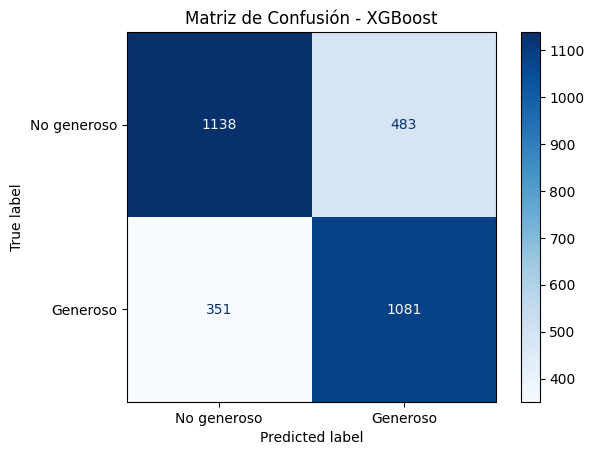

In [51]:
# Generate array of values for confusion matrix
#==> ENTER YOUR CODE HERE
# Generate array of values for confusion matrix
cm = confusion_matrix(y_test, xgb_preds, labels=xgb1.classes_)

# Plot confusion matrix
#==> ENTER YOUR CODE HERE

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No generoso', 'Generoso'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - XGBoost')
plt.show()


**Pregunta:** ¿Qué tipo de errores son más comunes para tu modelo?


==> INGRESE SU RESPUESTA AQUÍ


##### Importancia de las características

Utilice el atributo `feature_importances_` del objeto del mejor estimador para inspeccionar las características de su modelo final. Luego puede ordenarlas y graficar las más importantes.


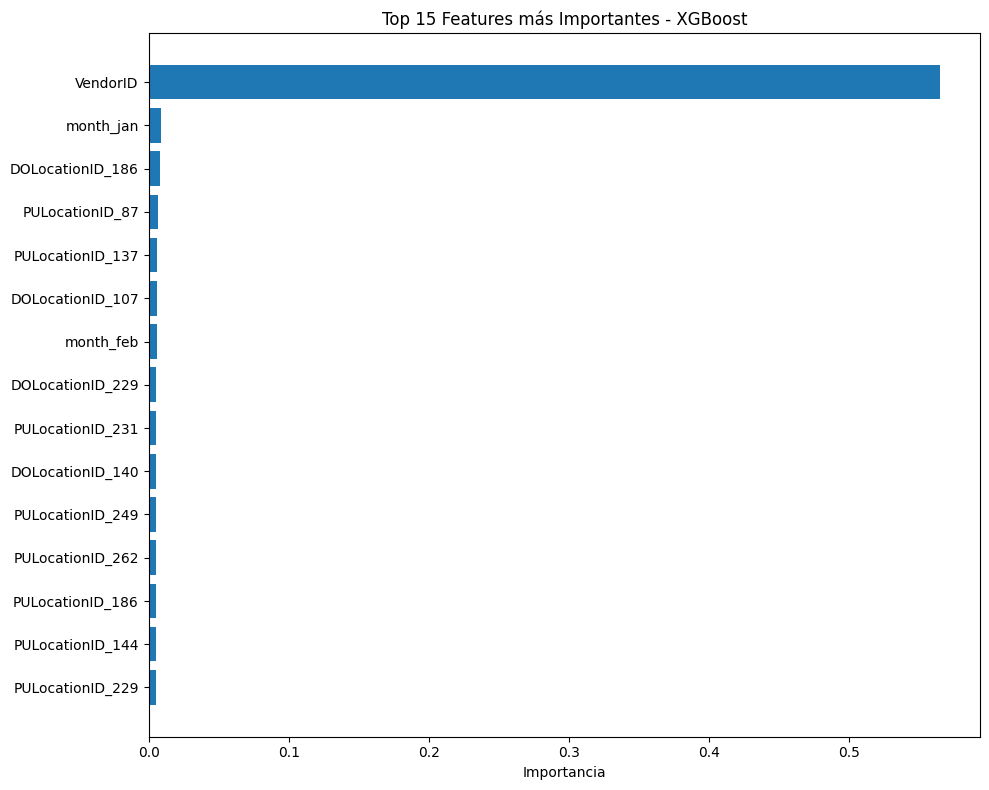

In [52]:
#==> ENTER YOUR CODE HERE
# Get feature importances from the best model
importances = xgb1.best_estimator_.feature_importances_

# Create a DataFrame
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

# Sort by importance
feat_imp = feat_imp.sort_values('importance', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['feature'][:15], feat_imp['importance'][:15])
ax.set_xlabel('Importancia')
ax.set_title('Top 15 Features más Importantes - XGBoost')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


<img src="images/Execute.png" width="100" height="100" align=left>

## PACE: **Ejecutar**

Considere las preguntas en su Documento de Estrategia PACE para reflexionar sobre la etapa de Ejecutar.


### **Tarea 4. Conclusión**

En este paso, use los resultados de los modelos anteriores para formular una conclusión. Considere las siguientes preguntas:

1. **¿Recomendaría usar este modelo? ¿Por qué o por qué no?**  

2. **¿Qué estaba haciendo su modelo? ¿Puede explicar cómo estaba haciendo predicciones?**   

3. **¿Hay nuevas características que pueda crear que podrían mejorar el rendimiento del modelo?**   

4. **¿Qué características le gustaría tener que probablemente mejorarían el rendimiento de su modelo?**   

Recuerde, a veces sus datos simplemente no serán predictivos de su objetivo elegido. Esto es común. El aprendizaje automático es una herramienta poderosa, pero no es magia. Si sus datos no contienen señal predictiva, incluso el algoritmo más complejo no podrá ofrecer predicciones consistentes y precisas. No tenga miedo de llegar a esta conclusión. Incluso si no puede usar el modelo para hacer predicciones fuertes, ¿el trabajo realizado fue en vano? Considere cualquier idea que pueda reportar a los interesados.


**¡Felicidades!** Has completado este laboratorio. Sin embargo, es posible que no notes una marca de verificación verde junto a este elemento en la plataforma de Coursera. Por favor, continúa con tu progreso independientemente de la marca de verificación. Solo haz clic en el icono de "guardar" en la parte superior de este cuaderno para asegurarte de que tu trabajo haya sido registrado.
